# Estimate Demand System — Tanzania (Hicks)

## EEP 153 — Project 3

**Deliverable:** Estimate a system of demands for different kinds of food. Characterize how consumption varies with household needs.

**Data Source:** [Tanzania - Hicks Google Sheet](https://docs.google.com/spreadsheets/d/1LRe2bjhimuwrTXU8MpmQFH02MJegNRpmwNkY9T3HGqA/edit)

**Survey Waves:** 2019-20 and 2020-21

---


In [1]:
# Install required packages (run once)
!pip install -r requirements.txt

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from cfe import Regression
import cfe

%matplotlib inline

## 0. Google Sheets Reader (No Authentication Needed)

We bypass `eep153_tools.sheets.read_sheets` (which requires a GPG passphrase) by reading the Google Sheet directly via its public export URL. 

**Requirement:** The Google Sheet must be accessible (shared as "Anyone with the link can view"). If it's not, you'll need to either:
1. Ask the sheet owner to make it viewable, or
2. Use "File → Share → Publish to the web" in Google Sheets for each tab, or
3. Get the GPG passphrase from your instructor/teammates


In [14]:
def read_google_sheet(spreadsheet_id, sheet_name):
    """
    Read a Google Sheet tab as a DataFrame.
    Requires the sheet to be shared as 'Anyone with the link can view'.
    """
    import urllib.parse
    encoded = urllib.parse.quote(sheet_name)
    url = f"https://docs.google.com/spreadsheets/d/{spreadsheet_id}/gviz/tq?tqx=out:csv&sheet={encoded}"
    df = pd.read_csv(url)
    print(f"  ✓ Loaded '{sheet_name}': {df.shape[0]} rows × {df.shape[1]} columns")
    return df

In [15]:
# Google Sheet key for Tanzania - Hicks data
Tanzania_Data = '1LRe2bjhimuwrTXU8MpmQFH02MJegNRpmwNkY9T3HGqA'


## 1. Load Data from Google Sheets

The Tanzania - Hicks spreadsheet contains data from **two survey waves** (2019-20 and 2020-21).

| Sheet | Columns | Description |
|-------|---------|-------------|
| `Household Characteristics` | `i, t, m` + demographic counts + `log HSize` | Household composition |
| `Food Expenditures (2019-20)` | `i, t, m, j, Expenditure` | Household food spending, wave 1 |
| `Food Expenditures (2020-21)` | `i, t, m, j, Expenditure` | Household food spending, wave 2 |
| `Food Prices (2019-20)` | `t, m, j, u, Price` | Market food prices, wave 1 |
| `Food Prices (2020-21)` | `t, m, j, u, Price` | Market food prices, wave 2 |


### 1.1 Food Expenditures (Both Waves)


In [16]:
# Read food expenditure data for BOTH survey waves
print("Loading expenditure data...")
x_2019 = read_google_sheet(Tanzania_Data, 'Food Expenditures (2019-20)')
x_2020 = read_google_sheet(Tanzania_Data, 'Food Expenditures (2020-21)')

# Combine both waves
x = pd.concat([x_2019, x_2020], ignore_index=True)

# Set multi-index: household (i), time (t), region (m), food item (j)
x = x.set_index(['i', 't', 'm', 'j']).squeeze()

# Handle any duplicate entries by summing
x = x.T.groupby(['i', 't', 'm', 'j']).sum()

# Replace zeros with NaN (missing data, not zero consumption)
x = x.replace(0, np.nan)

# Take logs of expenditures — dependent variable for our regression
y = np.log(x)

print(f"\nTotal expenditure observations: {len(y)}")
print(f"Unique households: {y.index.get_level_values('i').nunique()}")
print(f"Time periods: {y.index.get_level_values('t').unique().tolist()}")
print(f"Regions: {y.index.get_level_values('m').unique().tolist()}")
print(f"Food items ({y.index.get_level_values('j').nunique()}):")
for item in sorted(y.index.get_level_values('j').unique()):
    print(f"  - {item}")


Loading expenditure data...
  ✓ Loaded 'Food Expenditures (2019-20)': 15581 rows × 5 columns
  ✓ Loaded 'Food Expenditures (2020-21)': 5728 rows × 5 columns

Total expenditure observations: 21309
Unique households: 1516
Time periods: ['2019-20', '2020-21']
Regions: ['Mainland Rural', 'Dar Es Salaam', 'Mainland Other Urban', 'Zanzibar']
Food items (59):
  - Beef
  - Bottled Beer
  - Bread
  - Buns, Cakes And Biscuits
  - Butter, Etc.
  - Cassava Dry/Flour
  - Cassava Fresh
  - Chicken
  - Citrus Fruits
  - Coconuts
  - Coffee & Cocoa
  - Cooking Oil
  - Dairy Products
  - Eggs
  - Fish (dried)
  - Fish (fresh)
  - Goat Meat
  - Groundnuts
  - Honey, Syrups, etc.
  - Irish Potatoes
  - Leafy Greens
  - Local Brews
  - Macaroni, Spaghetti
  - Maize (flour)
  - Maize (grain)
  - Maize (green, cob)
  - Materials For Drinks
  - Milk (dry or canned)
  - Milk (fresh)
  - Millet & Sorghum (flour)
  - Millet & Sorghum (grain)
  - Nuts
  - Other Cereal Products
  - Other Cereals
  - Other Fruits


### 1.2 Food Prices (Both Waves)

We compute median prices per (time, region, good, unit) and keep only `kg` prices for consistency.


In [17]:
# Read food price data for BOTH survey waves
print("Loading price data...")
p_2019 = read_google_sheet(Tanzania_Data, 'Food Prices (2019-20)')
p_2020 = read_google_sheet(Tanzania_Data, 'Food Prices (2020-21)')

# Combine both waves
p = pd.concat([p_2019, p_2020], ignore_index=True)
p = p.set_index(['t', 'm', 'j', 'u'])

# Compute median prices for each (time, region, good, unit)
p = p.groupby(['t', 'm', 'j', 'u']).median()

# Keep only kg-denominated prices for consistency
p = p.xs('kg', level='u').squeeze().unstack('j')

# Keep only goods that appear in BOTH expenditure and price data
jidx = p.columns.intersection(x.index.get_level_values('j').unique())
p = p[jidx].T

print(f"\nFoods with both price and expenditure data: {len(jidx)}")
print(f"Price matrix shape: {p.shape}")
p.head(10)


Loading price data...
  ✓ Loaded 'Food Prices (2019-20)': 223 rows × 5 columns
  ✓ Loaded 'Food Prices (2020-21)': 245 rows × 5 columns

Foods with both price and expenditure data: 59
Price matrix shape: (59, 8)


t                              2019-20                                      \
m                        Dar Es Salaam Mainland Other Urban Mainland Rural   
j                                                                            
Beef                       6532.211538          5666.949153    5630.612245   
Bottled Beer               4538.028312          3753.968254    4095.238095   
Bread                      2422.510735          2243.097163    2051.672190   
Buns, Cakes And Biscuits   2538.132713          2585.787017    2481.803693   
Butter, Etc.               8133.333333          8250.000000    6000.000000   
Cassava Dry/Flour          1370.000000          1095.726496     768.049853   
Cassava Fresh               952.240521           925.610318     702.739507   
Chicken                   11196.825400          8615.935263    7566.464785   
Citrus Fruits              2480.320538          2113.435588    1742.480205   
Coconuts                   1764.239980          1616.568308    1381.141226   

t                                           2020-21                       \
m                            Zanzibar Dar Es Salaam Mainland Other Urban   
j                                                                          
Beef                      9090.909091   7526.388889          6785.185185   
Bottled Beer                      NaN           NaN          4285.714286   
Bread                     2590.391156   2971.958787          2435.407982   
Buns, Cakes And Biscuits  4075.000000   2479.066073          2671.570399   
Butter, Etc.              5100.000000           NaN          8750.000000   
Cassava Dry/Flour         1500.000000   1000.000000           770.000000   
Cassava Fresh             1268.796992    974.443404           826.244869   
Chicken                   9250.000000   8262.755102         10240.000000   
Citrus Fruits             2363.636364   1672.191367          1193.091267   
Coconuts                  1445.505148   1553.931005          1623.831637   

t                                                      
m                        Mainland Rural      Zanzibar  
j                                                      
Beef                        6294.871795  10200.000000  
Bottled Beer                3825.757576           NaN  
Bread                       2260.791548   3289.193779  
Buns, Cakes And Biscuits    3229.608336   2177.358491  
Butter, Etc.                4000.000000   4000.000000  
Cassava Dry/Flour            697.500000           NaN  
Cassava Fresh                600.867540   1500.000000  
Chicken                     4333.333333   9500.000000  
Citrus Fruits               1084.164209   1810.606061  
Coconuts                     975.978483   1418.492581

### 1.3 Household Characteristics

Demographic variables: counts of household members by age-gender group (Males 00-03, Females 00-03, ..., Males 51-99, Females 51-99) plus `log HSize`.


In [18]:
# Read household characteristics
print("Loading household characteristics...")
d = read_google_sheet(Tanzania_Data, 'Household Characteristics')
d.columns.name = 'k'

# Fill missing values with zeros
d = d.replace(np.nan, 0)

# Set index to match expenditure data structure
d.set_index(['i', 't', 'm'], inplace=True)

print(f"\nNumber of household observations: {len(d)}")
print(f"Demographic variables ({len(d.columns)}):")
for col in d.columns:
    print(f"  - {col}")

d.head()


Loading household characteristics...
  ✓ Loaded 'Household Characteristics': 22433 rows × 18 columns

Number of household observations: 22433
Demographic variables (15):
  - Males 00-03
  - Females 00-03
  - Males 04-08
  - Females 04-08
  - Males 09-13
  - Females 09-13
  - Males 14-18
  - Females 14-18
  - Males 19-30
  - Females 19-30
  - Males 31-50
  - Females 31-50
  - Males 51-99
  - Females 51-99
  - log HSize


k                                Males 00-03  Females 00-03  Males 04-08  \
i        t       m                                                         
0001-001 2012-13 Mainland Rural            0              0            0   
         2014-15 Mainland Rural            0              0            0   
0001-004 2014-15 Mainland Rural            1              0            0   
0002-001 2012-13 Mainland Rural            0              2            0   
         2014-15 Mainland Rural            2              0            0   

k                                Females 04-08  Males 09-13  Females 09-13  \
i        t       m                                                           
0001-001 2012-13 Mainland Rural              0            0              0   
         2014-15 Mainland Rural              0            0              0   
0001-004 2014-15 Mainland Rural              0            0              0   
0002-001 2012-13 Mainland Rural              2            0              0   
         2014-15 Mainland Rural              4            0              0   

k                                Males 14-18  Females 14-18  Males 19-30  \
i        t       m                                                         
0001-001 2012-13 Mainland Rural            0              0            4   
         2014-15 Mainland Rural            0              0            1   
0001-004 2014-15 Mainland Rural            0              0            1   
0002-001 2012-13 Mainland Rural            0              0            0   
         2014-15 Mainland Rural            0              0            0   

k                                Females 19-30  Males 31-50  Females 31-50  \
i        t       m                                                           
0001-001 2012-13 Mainland Rural              0            0              0   
         2014-15 Mainland Rural              0            1              0   
0001-004 2014-15 Mainland Rural              1            0              0   
0002-001 2012-13 Mainland Rural              2            2              0   
         2014-15 Mainland Rural              2            2              0   

k                                Males 51-99  Females 51-99  log HSize  
i        t       m                                                      
0001-001 2012-13 Mainland Rural            2              2   2.079442  
         2014-15 Mainland Rural            1              1   1.386294  
0001-004 2014-15 Mainland Rural            0              0   1.098612  
0002-001 2012-13 Mainland Rural            0              0   2.079442  
         2014-15 Mainland Rural            0              0   2.302585

## 2. Estimate the Demand System

The `cfe.Regression` model estimates:
- **β (beta):** How the budget share of each good changes with total expenditure (Engel curve slopes)
  - Positive β → luxury good (share rises with income)
  - Negative β → necessity (share falls with income)
- **γ (gamma):** How household demographics shift food demand patterns


In [21]:
# Estimate the demand system
result = Regression(y=y, d=d)

print("✓ Demand system estimated successfully!")

beta = result.get_beta()
goods_list = beta.index.tolist()
print(f"  Number of goods in system: {len(beta)}")
print(f"  Goods: {goods_list}")

✓ Demand system estimated successfully!
  Number of goods in system: 29
  Goods: ['Beef', 'Bread', 'Buns, Cakes And Biscuits', 'Cassava Fresh', 'Chicken', 'Citrus Fruits', 'Coconuts', 'Cooking Oil', 'Eggs', 'Fish (dried)', 'Fish (fresh)', 'Irish Potatoes', 'Leafy Greens', 'Macaroni, Spaghetti', 'Maize (flour)', 'Milk (fresh)', 'Other Fruits', 'Other Spices', 'Plantains', 'Pulses', 'Rice (husked)', 'Ripe Bananas', 'Salt', 'Soft drinks', 'Sugar', 'Sweet Potatoes', 'Tea (dry)', 'Vegetables (fresh)', 'Wheat Flour']


### 2.1 Model Fit — Predicted vs. Actual


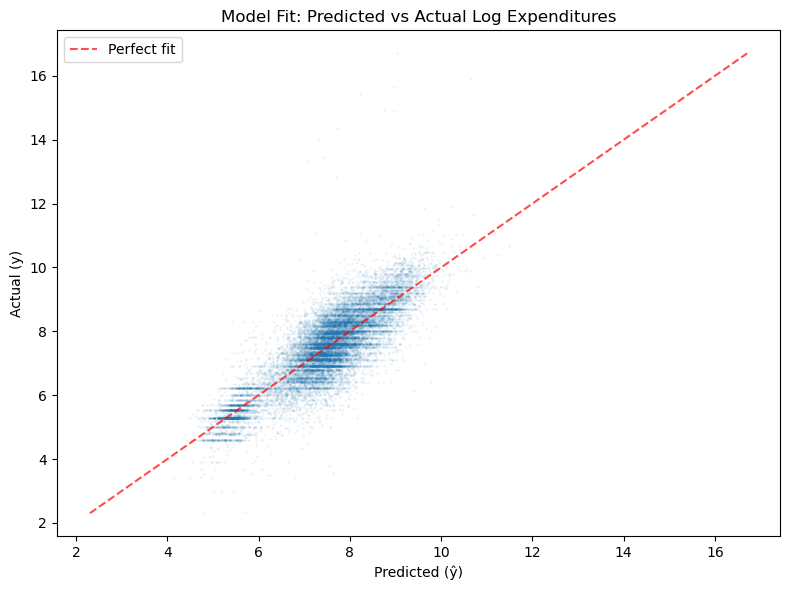

In [22]:
df_fit = pd.DataFrame({
    'Actual (y)': y,
    'Predicted (ŷ)': result.get_predicted_log_expenditures()
})

fig, ax = plt.subplots(figsize=(8, 6))
df_fit.plot.scatter(x='Predicted (ŷ)', y='Actual (y)', alpha=0.05, s=1, ax=ax)
lims = [df_fit.min().min(), df_fit.max().max()]
ax.plot(lims, lims, 'r--', alpha=0.7, label='Perfect fit')
ax.set_title('Model Fit: Predicted vs Actual Log Expenditures')
ax.legend()
plt.tight_layout()
plt.show()


### 2.2 Estimated β (Budget Elasticity Parameters)


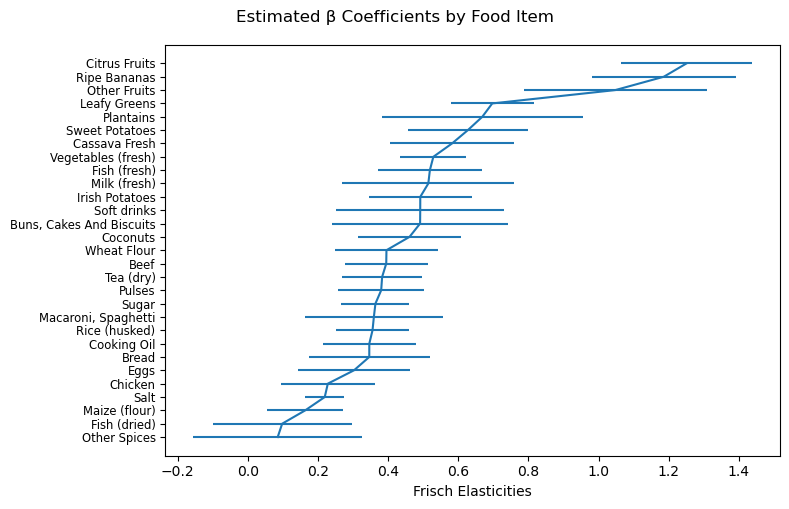

In [24]:
fig = result.graph_beta()
fig.suptitle('Estimated β Coefficients by Food Item')
fig.tight_layout()
plt.show()


In [25]:
beta = result.get_beta()
print("β (Budget Elasticity) Coefficients — sorted:")
print("\nNecessities (negative β — share falls as budget rises):")
print(beta[beta < 0].sort_values())
print("\nLuxuries (positive β — share rises as budget rises):")
print(beta[beta > 0].sort_values(ascending=False))


β (Budget Elasticity) Coefficients — sorted:

Necessities (negative β — share falls as budget rises):
Series([], Name: beta, dtype: float64)

Luxuries (positive β — share rises as budget rises):
j
Citrus Fruits               1.250915
Ripe Bananas                1.186054
Other Fruits                1.047823
Leafy Greens                0.696915
Plantains                   0.668549
Sweet Potatoes              0.627395
Cassava Fresh               0.582213
Vegetables (fresh)          0.528931
Fish (fresh)                0.519063
Milk (fresh)                0.514590
Irish Potatoes              0.491682
Soft drinks                 0.491544
Buns, Cakes And Biscuits    0.491180
Coconuts                    0.460999
Wheat Flour                 0.395246
Beef                        0.394625
Tea (dry)                   0.382893
Pulses                      0.380210
Sugar                       0.363795
Macaroni, Spaghetti         0.359340
Rice (husked)               0.355506
Cooking Oil               

### 2.3 Estimated γ (Household Characteristics Effects)


In [26]:
gamma = result.get_gamma()
print(f"γ matrix shape: {gamma.shape} (demographic groups × food items)")
gamma


γ matrix shape: (29, 16) (demographic groups × food items)


k,Males 00-03,Females 00-03,Males 04-08,Females 04-08,Males 09-13,Females 09-13,Males 14-18,Females 14-18,Males 19-30,Females 19-30,Males 31-50,Females 31-50,Males 51-99,Females 51-99,log HSize,Constant
j,,,,,,,,,,,,,,,,
Beef,0.077682,-0.005968,0.111223,-0.013025,-0.192215,-0.109427,0.005910,0.061885,0.004780,0.036174,0.161237,0.151777,0.195287,0.127008,0.230110,8.757647
Bread,-0.144494,-0.106851,-0.013777,0.148933,0.132345,0.148128,-0.048996,0.088761,0.002687,0.100339,0.229477,0.060044,0.103132,0.295171,0.069250,7.709530
"Buns, Cakes And Biscuits",0.010819,-0.036685,-0.028856,-0.078656,0.087289,0.020987,0.065805,0.226198,-0.045866,-0.002440,0.033185,-0.064457,0.077756,-0.037615,0.397207,7.433694
Cassava Fresh,0.026137,0.062127,-0.000151,0.019185,0.070276,0.133597,0.071796,-0.072334,0.096153,-0.030905,0.012677,-0.031762,0.055274,0.217517,0.290560,7.510538
Chicken,0.031111,-0.132517,0.080621,0.091843,-0.079714,0.096516,-0.255527,-0.074955,-0.156359,0.004110,-0.095286,0.001454,-0.005707,0.034354,0.455818,9.049572
Citrus Fruits,-0.270057,-0.083495,-0.253770,0.044515,0.045555,-0.095496,0.075231,-0.019145,-0.074248,-0.113014,-0.084554,-0.124245,-0.254391,0.130596,0.576627,6.905943
Coconuts,-0.081598,-0.101330,-0.007152,0.000079,-0.028668,0.004202,-0.072938,0.018634,-0.005096,0.008348,-0.034155,-0.036708,0.108692,0.113382,0.440262,7.847034
Cooking Oil,-0.072479,-0.025707,-0.134748,-0.048658,-0.025759,-0.022279,0.068460,0.029011,-0.013321,0.158009,0.122801,0.144997,-0.028088,0.019905,0.269062,7.413332
Eggs,-0.190926,0.018887,0.118880,0.034417,-0.112722,0.174081,-0.055745,0.059651,0.030172,0.170285,0.192240,0.084080,-0.035207,0.125922,0.133956,7.422005


### 2.4 Distribution of Household Budget Adequacy (w)

`w` is the residual capturing how much each household's spending deviates from what demographics predict — essentially a measure of budget adequacy.


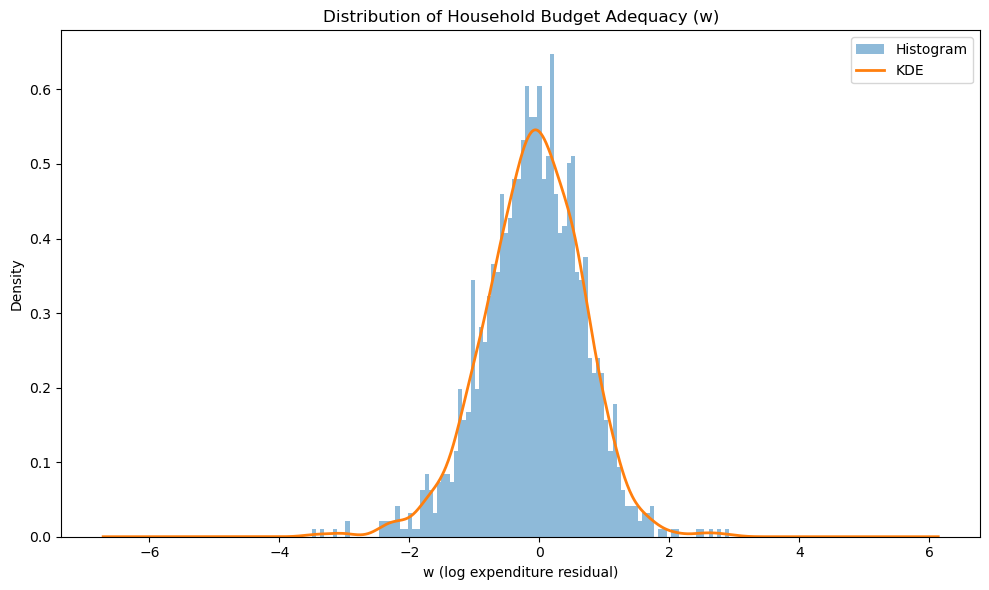

In [27]:
fig, ax = plt.subplots(figsize=(10, 6))
w = result.get_w()
w.plot.hist(bins=100, density=True, alpha=0.5, ax=ax, label='Histogram')
w.plot.kde(ax=ax, label='KDE', linewidth=2)
ax.set_xlabel('w (log expenditure residual)')
ax.set_ylabel('Density')
ax.set_title('Distribution of Household Budget Adequacy (w)')
ax.legend()
plt.tight_layout()
plt.show()


### 2.5 Save Estimation Results


In [28]:
result.to_pickle('tanzania_demand_estimates.rgsn')
print("✓ Saved to 'tanzania_demand_estimates.rgsn'")
print("  Load later with: result = cfe.regression.read_pickle('tanzania_demand_estimates.rgsn')")


✓ Saved to 'tanzania_demand_estimates.rgsn'
  Load later with: result = cfe.regression.read_pickle('tanzania_demand_estimates.rgsn')


## 3. Characterize How Consumption Varies with Household Needs


In [29]:
# Predicted expenditures and reference values
xhat = result.predicted_expenditures()
xbar = xhat.groupby(['i', 't', 'm']).sum()

xref_25 = xbar.quantile(0.25)
xref_50 = xbar.quantile(0.50)
xref_75 = xbar.quantile(0.75)

print(f"Household food budget distribution:")
print(f"  25th percentile: {xref_25:,.0f} TZS")
print(f"  Median:          {xref_50:,.0f} TZS")
print(f"  75th percentile: {xref_75:,.0f} TZS")


Household food budget distribution:
  25th percentile: 66,882 TZS
  Median:          87,769 TZS
  75th percentile: 113,204 TZS


In [30]:
# Reference prices
pbar = p.mean(axis=1)
pbar = pbar[result.beta.index]
pbar = pbar.replace(np.nan, 1)

print("Reference prices (TZS per kg):")
for item, price in pbar.sort_values().items():
    print(f"  {item:30s} {price:>10,.0f}")


Reference prices (TZS per kg):
  Cassava Fresh                         969
  Irish Potatoes                      1,145
  Salt                                1,179
  Plantains                           1,289
  Leafy Greens                        1,346
  Maize (flour)                       1,372
  Wheat Flour                         1,436
  Coconuts                            1,472
  Soft drinks                         1,514
  Sweet Potatoes                      1,549
  Other Fruits                        1,550
  Rice (husked)                       1,715
  Vegetables (fresh)                  1,736
  Ripe Bananas                        1,766
  Citrus Fruits                       1,807
  Milk (fresh)                        1,808
  Pulses                              2,265
  Bread                               2,533
  Sugar                               2,640
  Macaroni, Spaghetti                 2,699
  Buns, Cakes And Biscuits            2,780
  Cooking Oil                         4,173
 

In [31]:
def my_prices(p0, j, p=pbar):
    """Change price of good j to p0, holding all other prices fixed."""
    p = p.copy()
    p.loc[j] = p0
    return p


### 3.1 Demand Curves

Quantity demanded vs. price at different budget levels.


In [32]:
# List available food items
print("Available food items:")
for i, item in enumerate(pbar.index.tolist(), 1):
    print(f"  {i:2d}. {item}")


Available food items:
   1. Beef
   2. Bread
   3. Buns, Cakes And Biscuits
   4. Cassava Fresh
   5. Chicken
   6. Citrus Fruits
   7. Coconuts
   8. Cooking Oil
   9. Eggs
  10. Fish (dried)
  11. Fish (fresh)
  12. Irish Potatoes
  13. Leafy Greens
  14. Macaroni, Spaghetti
  15. Maize (flour)
  16. Milk (fresh)
  17. Other Fruits
  18. Other Spices
  19. Plantains
  20. Pulses
  21. Rice (husked)
  22. Ripe Bananas
  23. Salt
  24. Soft drinks
  25. Sugar
  26. Sweet Potatoes
  27. Tea (dry)
  28. Vegetables (fresh)
  29. Wheat Flour


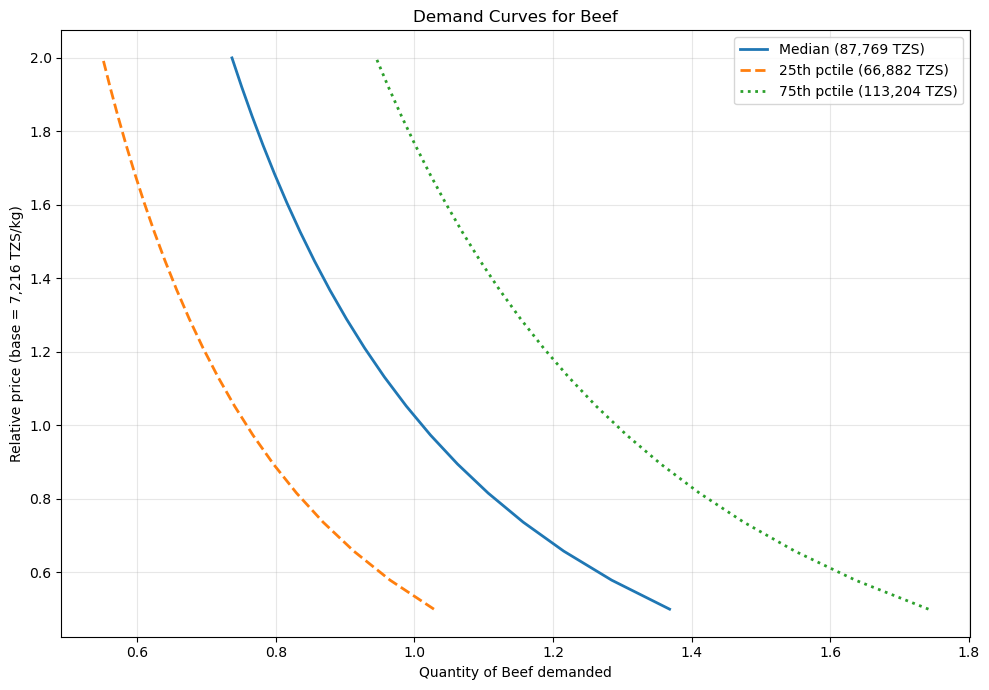

In [33]:
# === CHANGE 'use' TO THE FOOD YOU WANT TO ANALYZE ===
use = pbar.index[0]  # Default: first item

scale = np.linspace(0.5, 2, 20)

fig, ax = plt.subplots(figsize=(10, 7))
for xref, label, style in [
    (xref_50, f'Median ({xref_50:,.0f} TZS)', '-'),
    (xref_25, f'25th pctile ({xref_25:,.0f} TZS)', '--'),
    (xref_75, f'75th pctile ({xref_75:,.0f} TZS)', ':')
]:
    demands = [result.demands(xref, my_prices(pbar[use]*s, use, pbar))[use] for s in scale]
    ax.plot(demands, scale, label=label, linewidth=2, linestyle=style)

ax.set_ylabel(f"Relative price (base = {pbar[use]:,.0f} TZS/kg)")
ax.set_xlabel(f"Quantity of {use} demanded")
ax.set_title(f"Demand Curves for {use}")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


### 3.2 Engel Curves

How food budget shares change with total spending. Declining shares = necessities; rising shares = luxuries.


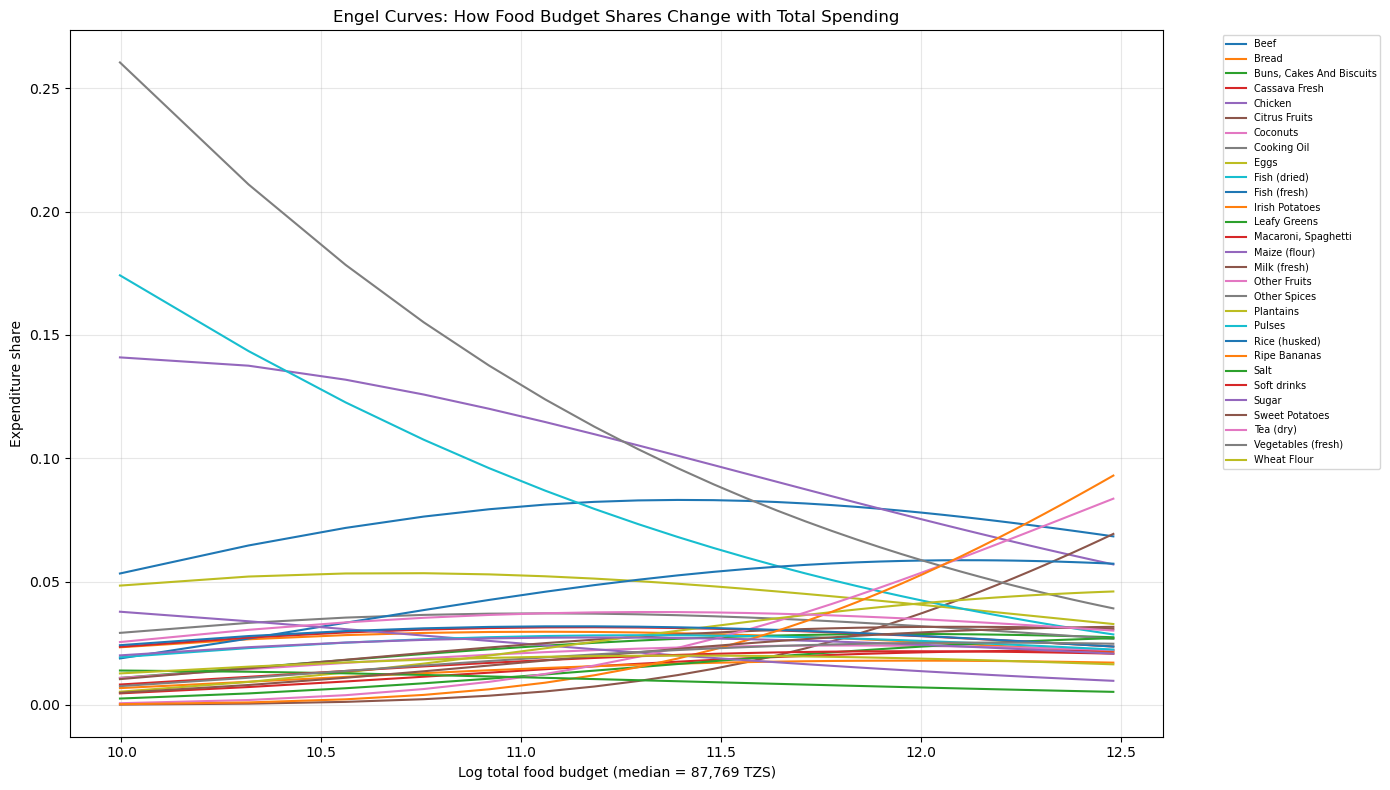

In [34]:
scale = np.linspace(0.25, 3, 30)

shares = [result.expenditures(s * xref_50, pbar) / (s * xref_50) for s in scale]
shares_df = pd.DataFrame(shares, index=np.log(scale * xref_50))

fig, ax = plt.subplots(figsize=(14, 8))
shares_df.plot(ax=ax, linewidth=1.5)
ax.set_xlabel(f'Log total food budget (median = {xref_50:,.0f} TZS)')
ax.set_ylabel('Expenditure share')
ax.set_title('Engel Curves: How Food Budget Shares Change with Total Spending')
ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=7)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


### 3.3 Indirect Utility


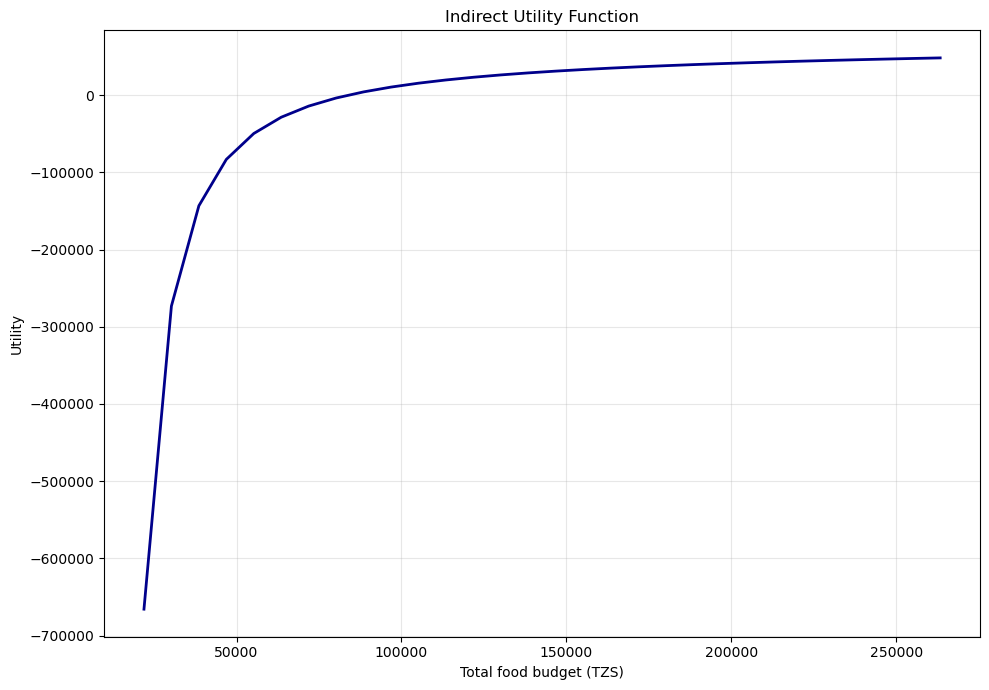

In [35]:
scale = np.linspace(0.25, 3, 30)

fig, ax = plt.subplots(figsize=(10, 7))
utilities = [result.indirect_utility(s * xref_50, pbar) for s in scale]
ax.plot(scale * xref_50, utilities, linewidth=2, color='darkblue')
ax.set_xlabel('Total food budget (TZS)')
ax.set_ylabel('Utility')
ax.set_title('Indirect Utility Function')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


## 4. Summary

This notebook estimates a complete food demand system for Tanzania using data from two survey waves (2019-20 and 2020-21):

1. **β coefficients** — identify necessities vs. luxuries
2. **γ coefficients** — capture how household demographics shift demand
3. **Demand curves** — show price responsiveness at different budget levels
4. **Engel curves** — reveal how budget shares evolve with income
5. **Indirect utility** — measures welfare as a function of budget

Saved results (`tanzania_demand_estimates.rgsn`) can be loaded for counterfactual experiments:
```python
result = cfe.regression.read_pickle('tanzania_demand_estimates.rgsn')
result.demands(budget, prices)        # Get demand quantities
result.indirect_utility(budget, prices) # Get welfare measure
```
